This notebook compares 4 different classification models, namely: K-nearest neighbours, logistic regression, decision trees, and Support Vector Machine (SVM).

To begin with I must explain what classification actually is in relation to machine learning. A classification algorithm is a machine learning algorithm focused on categorisation and it sorts input data into different categories or classes. An algorithm is a set of finite rules that obtains an expected output from a given input, the algorithm I use takes feature input(s) and outputs the expected class. Classification algorithms generally follow a two-step data classification process of learning and then classifying. Classification is a supervised learning approach since the data is labelled and because each input needs a corresponding category.

The class values of S and B are for Malware and Benign respectively, as seen in the "dataset-features-category.csv" file. So by predicting class it is predicting the classification of an input as either malicious or non-malicious (benign).

Step 1. Firstly, I start by setting up most of the necessary dependencies and libraries:

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import plot_tree
from sklearn import preprocessing
%matplotlib inline

# classification models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Model evaluation metrics
from sklearn import metrics

Step 2. Loading in both datasets, pre-processing, and checks.

These datasets are examples of structured data as CSVs are tabular, can be stored in relational databses, and are formatted in an easily searchable manner and follow a pre-determined schema. The drebin dataset consists of binary categorical data and a "class" label with nominal categorical data. The dataset-features-categories entries are categorical (self described) as well. Since there is no clear hierarchy or order the categorical data is nominal and not ordinal. It is also nominal since there are over 2 categories.

The drebin dataset is of the most importance as I will classify whether the software attributes are of class S or B, the dataset-features-categories.csv file provides a descriptor of each value in the vector and an explanation of the class.

.head() method is used to display the first 5 rows of the dataset and ensure data hygiene and that everything is displaying properly, it comes with the Pandas library (it is a method since it belongs to Pandas' DataFrame object).

"low_memory=False" since I got a "DtpeWarning: Columns (92) have mixed types. Specify dtype option on import or set low_memory=False". This means Pandas will load the entire file into memory at once and I used it since the automatic dtype inference was not correct.


In [66]:
cat_df =  pd.read_csv("dataset-features-categories.csv")
drebin_df =  pd.read_csv("drebin-215-dataset-5560malware-9476-benign.csv", low_memory=False)
# cat_df.head() # display first 5 rows
# drebin_df.head()
drebin_df.columns # view all columns in the dataset


Index(['transact', 'onServiceConnected', 'bindService', 'attachInterface',
       'ServiceConnection', 'android.os.Binder', 'SEND_SMS',
       'Ljava.lang.Class.getCanonicalName', 'Ljava.lang.Class.getMethods',
       'Ljava.lang.Class.cast',
       ...
       'READ_CONTACTS', 'DEVICE_POWER', 'HARDWARE_TEST', 'ACCESS_WIFI_STATE',
       'WRITE_EXTERNAL_STORAGE', 'ACCESS_FINE_LOCATION', 'SET_WALLPAPER_HINTS',
       'SET_PREFERRED_APPLICATIONS', 'WRITE_SECURE_SETTINGS', 'class'],
      dtype='object', length=216)

Step 3. Initial data visualisation using matplotlib and seaborn (using their industry standard aliases)

The target/dependent variable/y is whether the features are S or B class.

The bar graph plot below shows the distribution of classes and from there I can infer that my classification models should output more B classes than S classes (this is a new found metric I will use to determine model accuracy).

I tried to also use a scatter plot to plot class S and class B before drawing or attempting to draw a line of best fit to determine the linearity of the data but since all the data entries are binary there is no real spread and just a few dots, hence why this plot was better than that scatter plot. Moreover, since logistic regression is a variation of linear regression it is safe to state that the data is linear in its relationship as the relationship can be model with a straight line.

There are more benign software attributes than malicious ones as B has a larger value than S.

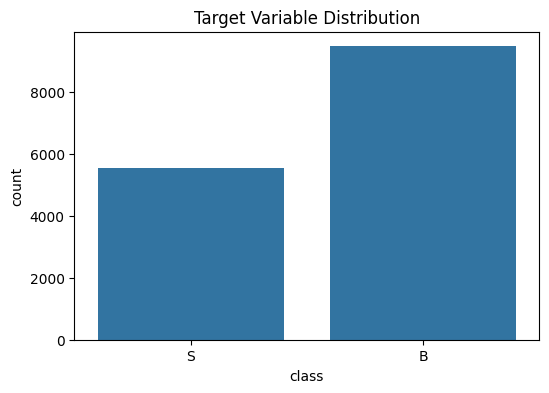

In [67]:
#  Visualisation 1: Class Balance 
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=drebin_df)
plt.title('Target Variable Distribution')
plt.show()

Step 4. Defining features and target variable 

(X variable was used. It is X since that is the mathematical symbol for features). The target variable/label is "class" and y is always the dependent variable (class is dependent on features).

I could have done X = drebin_df.drop(columns=["class"]) to specify the columns used for the features but since I already printed out all the columns my instictive thought was to just copy and paste all but the target into the features (target dropped since that is what I want to predict and it is not a feature, this prevents target data leakage), using the drop() method does make the code cleaner though (important for good practice and working in bigger codebases), albeit my code is still very readable. Target data leakage is when a model includes data that will not be available when the model is used for prediction.

All the other features were used since I felt they were relevant and would not create noise (noise as in irrelevant or erroneous data).

In [68]:
X = drebin_df[['transact', 'onServiceConnected', 'bindService', 'attachInterface',
       'ServiceConnection', 'android.os.Binder', 'SEND_SMS',
       'Ljava.lang.Class.getCanonicalName', 'Ljava.lang.Class.getMethods',
       'Ljava.lang.Class.cast',
       'READ_CONTACTS', 'DEVICE_POWER', 'HARDWARE_TEST', 'ACCESS_WIFI_STATE',
       'WRITE_EXTERNAL_STORAGE', 'ACCESS_FINE_LOCATION', 'SET_WALLPAPER_HINTS',
       'SET_PREFERRED_APPLICATIONS', 'WRITE_SECURE_SETTINGS']].values

y = drebin_df['class'].values
y[0:5] # show first 5 class values

array(['S', 'S', 'S', 'S', 'S'], dtype=object)

Step 5. Scaling/standardising the Features data

Although his step is unnecessary for decision trees as they do not operate on distance calculations and rather split the dataset into subsets based on feature values, effectively creating branches that lead to the ultimate prediction, it is crucial for the 3 remaining classification models and to ensure consistency of the training I cannot train the decision tree algorithm on unscaled data when the rest are trained on scaled data (that is not mathematical and is not good practic for data science).

I scaled instead of normalised as I do not want to change the distribution and shape of the data, the data already has a normal distribution. All I did with StandardScaler() was make each feature have a eman of zero and a variance of 1. Since there are no outliers RobustScaler() was not used and with scaling I have prevented a single feature from dominating the training process due to being much larger.



In [69]:
X = preprocessing.StandardScaler().fit(X).transform(X.astype(float))
X[0:5] # display the new scaled values of the first 5 rows

array([[-0.86, -0.9 , -0.89, -0.84, -0.9 , -0.97,  1.8 , -0.7 , -0.63,
        -0.67, -0.55, -0.13, -0.07, -0.88,  0.71, -0.64, -0.13, -0.08,
        -0.22],
       [-0.86, -0.9 , -0.89, -0.84, -0.9 , -0.97,  1.8 , -0.7 , -0.63,
        -0.67, -0.55, -0.13, -0.07, -0.88,  0.71, -0.64, -0.13, -0.08,
        -0.22],
       [-0.86, -0.9 , -0.89, -0.84, -0.9 , -0.97,  1.8 , -0.7 , -0.63,
        -0.67, -0.55, -0.13, -0.07, -0.88, -1.41, -0.64, -0.13, -0.08,
        -0.22],
       [-0.86, -0.9 , -0.89, -0.84, -0.9 , -0.97, -0.56, -0.7 , -0.63,
         1.48, -0.55, -0.13, -0.07,  1.14,  0.71,  1.56, -0.13, -0.08,
        -0.22],
       [-0.86, -0.9 , -0.89, -0.84, -0.9 , -0.97, -0.56, -0.7 , -0.63,
        -0.67, -0.55, -0.13, -0.07,  1.14, -1.41,  1.56, -0.13, -0.08,
        -0.22]])

Step 6. Train Test Split

The main purpose of ML models is to ensure a good out of sample accuracy (how correct the classifications are on data the model was not trained on) and that the model is not overfitted (too fine tuned to training data and poorly performing on out of sample/unseen data). One way to do so is to do a train test split, where the test data is the validation data to test the model accuracy.

80/20 split is seen as the standard/defacto split so that is what I go with, the random_state seed is set to the static value of 4 to ensure reproducability (helps with debugging). The .shape method is from Pandas and is used to get the dimensions of the train and test data.

In [71]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (12028, 19) (12028,)
Test set: (3008, 19) (3008,)


Step 7.0 - 1st Classification Model, K-Nearest Neighbours (KNN)

Building the model.

KNN is a supervised ML algorithm mainly used for classification (could also be used for regression). In the context of classification, it operates by finding the "k" nearest data points (neighbours) to a given input and makes predictions off of the majority class. KNN makes no assumptions about the underlying data distribution and performs computations only at the time of classification, after it stores the whole dataset.

In layman terms it finds a set amount (this set amount is k) of closest points to a data input and if most of the closest points belong to category Alpha then the data point is classified as category Alpha. This is why scaling was important because in distance calculations skewed data points that are super far off could impact accuracy as it could favour features with larger scales (not too dire since all the data in the drebin dataset have a good raneg to begin with).

the k variable is initially set to 4 but I will experiment with that value later. The neigh object was created with the number of neighbours being the value of the k variable, KNeighborsClassifier from scikit-learn specified and .fit() method is used to train the data and calculate requisite parameters. KNN also does not randomly plot data points like K-Means clustering does.

In [82]:
k = 9
#Train Model and Predict  
neigh = KNeighborsClassifier(n_neighbors = k).fit(X_train,y_train)
neigh

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Step 7.1 - KNN predictions on the test data

y with a ^ directly above it (this is how the symbol looks) or as it is pronounced "y hat" is the mathematical term for the predicted y (dependent variable) value and can be used to measure the difference between the model's predicted y values and the ground truth/actual y values (this difference is called loss).

yhat variable is initialised with the value of the precition of y based off of the test feature data assigned to it. After which the first 5 predictions (first 5 positions in the array, starting from 0 and stopping before 5) are displayed.

In [83]:
yhat = neigh.predict(X_test)
yhat[0:5]

array(['B', 'S', 'B', 'S', 'S'], dtype=object)

Step 7.2 - KNN Accuracy Evaluation

To evaluate the accuracy I compare the accuracy score of the predictions of both the train and test data against each other. 1.0 means it is 100% accurate since 1.0 is the decimal representation of 100%. As shown by the accuracy score the model is more accurate on the test/out of sample/validation dataset than the training set (just by ~0.0006 or so). This is for when k = 4. This means that the model predicts classes/categories to a very high accuracy and since the test set is more accurate than the training set it is most probably an indication that the model is well fitted and performs very well when k= 4.

All of the classifications are binary  classificatios as there are only 2 distinct classes of S and B.

In [84]:
print("Train set Accuracy: ", metrics.accuracy_score(y_train, neigh.predict(X_train)))
print("Test set Accuracy: ", metrics.accuracy_score(y_test, yhat))

Train set Accuracy:  0.9153641503159295
Test set Accuracy:  0.9202127659574468


Step 7.3 Experimenting with other k values

The number of Ks is initialised to 10 but Python stops counting before 10 so in actuality the range is 1-9 (9 k values).

"mean_acc = np.zeros((Ks-1))" create an array filled with zeros to store the mean accuracy for each k value (10 - 1 ensures it goes from 9 to 1, the k value of 0 means there will be no calculation), then a corresponding variable for the standard deviation accuracy for each k value.

The reason mean is calculated is for distance calculations where calculating the average allows the model to centre the data by subtracting the mean from every data point until the dataset does not move (similar to K-means clustering). Standard deviation is taken to see the spread of the data.

Then the code trains the model for a loop of 9 times where in every loop the number of nearest neighbours (k) is set to the current numerical value of the iteration of the loop, and for each k value the model is trained and tries to predict the classes of unseen data (yhat line).

The mean accuracy score uses the built in metrics method from sklearn and the parameters y_test and yhat are passed into that function. Standard deviation accuracy is calculated using Numpy (much of this code for KNN is repurposed from IBM's week 5 KNN Jupyter notebook).

In [85]:
Ks = 10
mean_acc = np.zeros((Ks-1))
std_acc = np.zeros((Ks-1))

for n in range(1,Ks): # in range of 1 to 9
    
    #Train Model and Predict  
    neigh = KNeighborsClassifier(n_neighbors = n).fit(X_train,y_train)
    yhat=neigh.predict(X_test)
    mean_acc[n-1] = metrics.accuracy_score(y_test, yhat)

    
    std_acc[n-1]=np.std(yhat==y_test)/np.sqrt(yhat.shape[0])

mean_acc

array([0.85, 0.91, 0.91, 0.92, 0.92, 0.92, 0.92, 0.92, 0.92])

Step 7.4.0 - Plotting the model accuracy for different numebrs of neighbours

Using matplotlib visualise the mean accuracy for all K values and the mean accuracy give or take 1 to 3 stds. 

'g' for green, plt.fill_between is used to create the shaded areas, legend shows the legend that displays what everything in the plot means (in maps it shows all symbols and POIs), tight_layout adjusts the paddings so all data is shown.

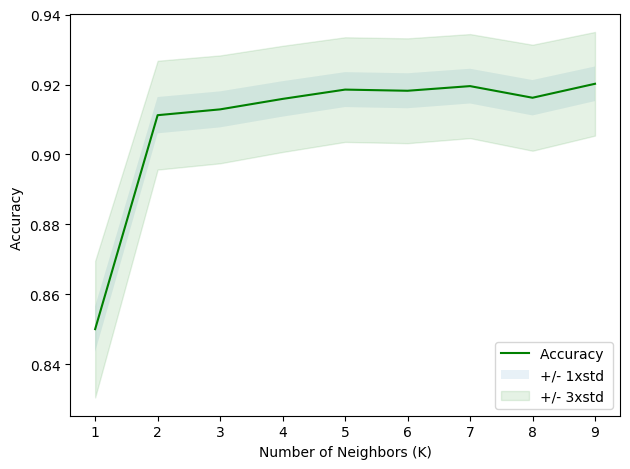

In [86]:
plt.plot(range(1,Ks),mean_acc,'g')
plt.fill_between(range(1,Ks),mean_acc - 1 * std_acc,mean_acc + 1 * std_acc, alpha=0.10)
plt.fill_between(range(1,Ks),mean_acc - 3 * std_acc,mean_acc + 3 * std_acc, alpha=0.10,color="green")
plt.legend(('Accuracy ', '+/- 1xstd','+/- 3xstd'))
plt.ylabel('Accuracy ')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()

Step 7.4.1 - Display best k value

The highest mean accuracy is the best, hence why I take the maximum mean value ("mean_acc.max()"). "mean_acc.argmax()+1" finds the index/position of the max value (since I am using the range of 1 to 10 and Python starts counting from zero +1 allows it to skip the 0th position that would be empty or useless as k cannot be 0 for functionality and performance reasons).

In [87]:
print( "The best accuracy was with", mean_acc.max(), "with k=", mean_acc.argmax()+1) 

The best accuracy was with 0.9202127659574468 with k= 9


Step 8. 2nd Classification Model, Logistic Regression

Building the model.

Now for an explanation of Logistic Regression (LR).
LR is similar to linear regression one exception though is that it predicts a categorical (discrete) target instead of a continuous variable. It predicts the probability that a given input belongs to a specific class annd is used for binary classification. 

LR also uses the sigmoid function to convert inputs into a probability value that lies between 0 and 1. Since the dataset has only 2 classes I will use binomial LR.

In the code, the C parameter represents the inverse of regularisation strength, it must be a positive float. Regularisation is  a mechanism for penalising model complecity when it is being trained and is highly important in LR. Without it the asymptotic nature of LR would continue to drive the loss towards 0 in scenarios where the model has a large number of features (kind of like this case). LR uses log loss.

"liblinear" is the initial numerical optimiser that I have chosen, it is a good solver for my use case as it works well on small-medium datasets like these current ones I am analysing.

In [88]:
LR = LogisticRegression(C=0.01, solver='liblinear').fit(X_train,y_train)
LR

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


Step 8.1 - LR Prediction using the test case

The first 3 predictions match my KNN's first 3 yhat predictions.

In [89]:
yhat = LR.predict(X_test)
yhat

array(['B', 'S', 'B', ..., 'B', 'B', 'S'], shape=(3008,), dtype=object)

Step 8.1.1 - LR prediction of the probability that a data entry in a test feature belongs to either class.

The first column is for class B and the second column is for class S (it is ordered alphabetically by the label of classes), thus the code below predicts/estimates the probability that a data entry in  any of the features in the test dataset for features (X) belongs to either class B or Class S. The print statement in the code cell directly below the predict_proba function is used to display classes, more specifically the order of these classes to prove that it is in fact alphabetical.

In [90]:
yhat_prob = LR.predict_proba(X_test)
yhat_prob

array([[0.79, 0.21],
       [0.09, 0.91],
       [0.91, 0.09],
       ...,
       [0.96, 0.04],
       [0.79, 0.21],
       [0.15, 0.85]], shape=(3008, 2))

In [91]:
print(LR.classes_)

['B' 'S']


Step 8.2 - Evaluating the accuracy of LR

Firstly, the Jaccard index or Jaccard similarity coefficient is the size of the intersection divided by the size of the union of the two label sets, it is used to compare a set of predicted labels for a sample to their corresponding actual set of labels. If the entire predicted set strictly matches the true set then the Jaccard score is 1.0, if not then it is 0.0. I used the true set abd test for class B labels by specifiying it in pos_label and got a score of 0.82 (rounded to 2dp), whereas for S I got a score of 0.73 (rounded to 2dp). B class predictions are probably more accurate since there is a greater distribution of B class labels.

Defined which the submodule I want from metrics.

In [92]:
from sklearn.metrics import jaccard_score
jaccard_score(y_test, yhat,pos_label="S")

0.7282204020848846

Step 8.2.1 - Evaluation of LR using a Confusion Matrix

More imports just incase. Sklearn and matplotlib used for calculations and data visualisation respectively.

In [93]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalisation can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalised confusion matrix")
    else:
        print('Confusion matrix, without normalisation')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
print(confusion_matrix(y_test, yhat, labels=["S","B"]))

[[ 978  161]
 [ 204 1665]]


The top left of the confusion matrix represents true positive (TP) usually but in this case it is how many predicted S class labels are actually class S. Bottom left is false positive (FP) where I see that 204 predicted S classes were incorrect.

Bottom right is True Negative (TN) which shows how many predicted class B outputs were actually class B, and lastly the top right which represents False Negative (FN) and shows how many predicted class B labels were actually class S. Basically the top row is for S and the first column is for S, the top left overlab means all S guesses there were correct, whilst the 2nd/bottom row is for B and the 2nd column is class B so the overlap in the bottom right shwos all correct B class guesses that were actually B. The whole false and true part means in this case S is "positive" and B is "negative".

Normailasrion in a confusion matrix means converting the raw counts into percentages. When I make normalize=True I find that the S class predictions are correct 86% of the time (TP) and highly accurate, and the class B predictions were correct 89% of the time (TN) and 82 was denoted by 0.82 whereas 89 was denoted by 0.89 in the bottom right. So far the model is highly accurate but not better than KNN where k is 9.

Confusion matrix, without normalisation
[[ 978  161]
 [ 204 1665]]


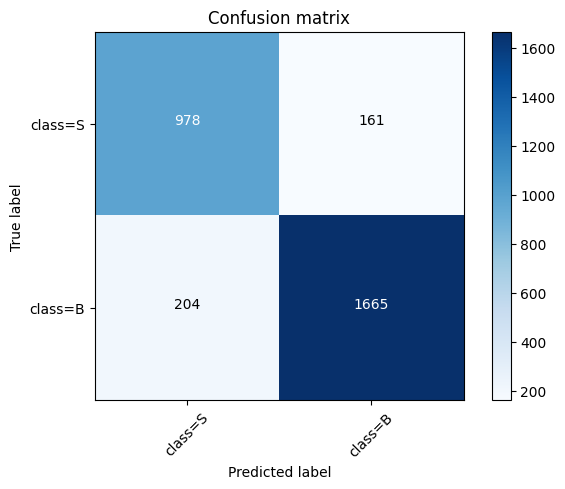

In [94]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, yhat, labels=["S","B"])
np.set_printoptions(precision=2)


# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['class=S','class=B'],normalize= False,  title='Confusion matrix')

The classification report in the cell below shows that the model is good at predicting positives since the recall (TP divided by TP+FN) is in the high 80s for class B (0.89) and mid 80s for class S (0.86). Recall shows the proportion of TPs detected out of all the actual positive instances, whereas precision focuses on the quality of the model's positive predictions by saying how many of the positive predictions were genuinely correct (found by dividing TP by TP+FP). I found that overall the predictions for class B and class S had a high percentage of being correct (via normalising earlier) but now it is time to find the complete accuracy which shows how many predictions the model got right out of all the predictions.

Accuracy gives an idea of the overall model performance and since I scaled it won't really be misleading as class B is not overly dominant over class S. Accuracy is found by the calculation (TP+TN)/(TP+TN+FP+FN) where "/" is the mathematical and computing operator or rather symbol for division and the brackets are used for readability.

Now to plug in the values: (978+1665)/(978+1665+204+161) = 0.88, rounded to the nearest 2dp (this decimal can be represented as 88% accuracy by multiplying by 100, thus the accuracy is 88%). This is still laess accurate than KNN with a k val of 9.

In [95]:
print (classification_report(y_test, yhat))

              precision    recall  f1-score   support

           B       0.91      0.89      0.90      1869
           S       0.83      0.86      0.84      1139

    accuracy                           0.88      3008
   macro avg       0.87      0.87      0.87      3008
weighted avg       0.88      0.88      0.88      3008



Step 8.2.2 - Evaluation of LR using log loss

A log loss of 0 is the perfect score  and means the model predicted the correct class with 100% confidence every time so my log loss score that is close to it and below the random guess threshold shows the great prediction power of mymodel and is acceptable for binary classification (my use case). Log Loss evaluates and accounts for model confidence which is an important metric for LR and model confidence is something accuracy does not consider.

In [96]:
from sklearn.metrics import log_loss
log_loss(y_test, yhat_prob)

0.27542903871006147

Step 9. the 3rd Classification Model - Support Vector Machine (SVM)

SVM is yet another supervised learning algorithm and technique (all classifications are supervised learning as stated prior) that can be used for regression and classification (the relevant use case now) activities. It tries to find the optimal boundary (called a hyperplane) that separates different classes in the data. SVM works well for binary classification and han dles high dimensional data better than KNN. The primary objective of SVM is to maximise the margin between the 2 classes as the larger the margin the better the model performs on unseen data.

The closest data points closest to the hyperlane are called support vectors, these are crucial for determining the hyperlane and margin (the distance between the hyperplane and the support vectors) in SVM. The kernel is a function that maps data to a higher-dimensional space, this enables SVM to handle non-linearly seprable data. Some types of kernels are: Linear, Polynomial, Sigmoid, and Radial Basis Function (RBF).

The best hyperplane (known as the hard margin) is the one that maximises the distance between the hyperplane and the closest data points (support vectors) from both classes, this can be found using gradient descent. This ensures an obvious separation between the classes and shows that the data points are clearly part of whichever distinct class. One strength of SVM is that it is robust to outliers.

I will experiment with different kernels, mainly Linear and RBF. Linear to see if it is linearly seperable and RBF to experiment with highly non-linear class boundaries.


High dimensional data is data with a large number of features or another explanation I saw from Statology is that it refers to datasets with a larger number of features than observations. Since GeeksforGeeks and other sources corroborate with the second point then my data is high dimensional as there are more featrues than samples/observations, thus my KNN model may be overfitted as the model may have learned noise instead of patterns.

The code imports the svm package, clf variable stands for classifier where the kernel is specified and then the model is trained.



In [97]:
from sklearn import svm
clf = svm.SVC(kernel='rbf')
clf.fit(X_train, y_train) 

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Predict new values with the test data

In [98]:
yhat = clf.predict(X_test)
yhat [0:5]

array(['B', 'S', 'B', 'S', 'S'], dtype=object)

Step 9.1 - SVM Model Evaluation using a confusion matrix

In [99]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalisation can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalised confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

              precision    recall  f1-score   support

           B       0.93      0.94      0.94      1869
           S       0.90      0.89      0.89      1139

    accuracy                           0.92      3008
   macro avg       0.92      0.91      0.91      3008
weighted avg       0.92      0.92      0.92      3008

Confusion matrix, without normalization
[[1010  129]
 [ 113 1756]]


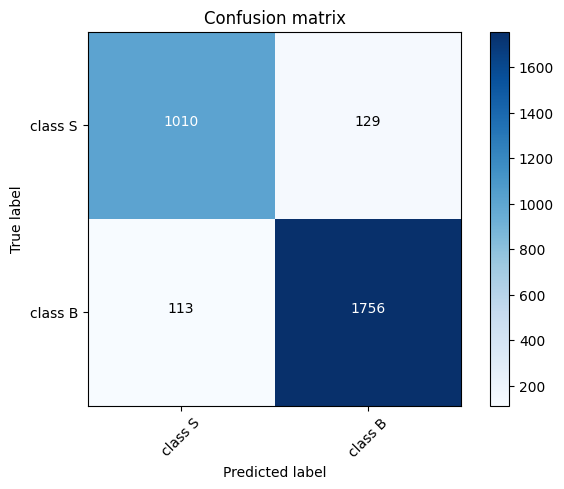

In [100]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, yhat, labels=["S","B"])
np.set_printoptions(precision=2)

print (classification_report(y_test, yhat))

# Plot non-normalised confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['class S','class B'],normalize= False,  title='Confusion matrix')

Class B is predicted correctly 94% of the time and class S is predicted correctly 89% of the time when the kernel is RBF(kernel = 'rbf').
With Linear('linear') class B TN is 0.93, class S TP is 0.82. For polynomial ('poly') class B TN is 0.94 and class S TP is 0.88. Since I have already done most of the kernels (more experimentation than I initially stated) I will use the sigmoid ('sigmoid' in Python code) kernel as my last kernel comparison. The sigmoid kernel faired the worst with the class B TN being 0.84 and class S TP being 0.78. Since RBF faired the best I will change the kernel back to rbf and make normalization (American spelling since Python uses American English) = False again.

The fact that RBF performed the best implies that the data is more complex and is actually more nonlinear as opposed to my conjecture that it was linear.

To evaluate the accuracy I will do  the calculation (TP+TN)/(TP+TN+FP+FN) where "/" is the mathematical and computing operator or rather symbol for division and the brackets are used for readability.

Now to plug in the values: (1010+1756)/(1010+1756+113+129) = 0.92, rounded to 2dp. This matches the accuracy the model calculated.

The f1 score in the cell directly below is a performance metric that evaluates how well a classification model performs on a dataset especially when the classes are imbalanced (when one class appears much more than another, not really the case in this dataset). F1 Score is the harmonic mean (harmonic mean over arithmetic mean as it better handles rates like recall and precision) of precision and recall and it combines both metrics into a single value that balances their importance. F1 score is calculated by the formula 2 x (PxR)/(P+R) where "P" is precision and "R" is recall, and / is for the division operation. An F1 score of 1 means that the model perfectly categorises each prediction into the right class and 0 means all predicted classes are incorrect (thus the higher the F1 score the better). Meaning this model's F1 score of 0.94 is really great.

For class S predictions, as shown by this model's jaccard score is extremely similar if not identical in jaccard scores as LR (most likely identical, I am adding some allowance for human error in my reading, if not identical then whatever hypothetical difference is negligible and miniscule). Important Edit: The jaccard score is identical even when LR and SVM assigned different predictions to the yhat variable, I will no longer use this as an evaluation metric for comparison of models.


I am importing dependencies as I go (depending on when I need them) which is a bit suboptimal as ideally everything needed would be imported at the start as that would be more professional since all viewers of the codebase would be able to see all the imports in one location, but I digress.

In [101]:
from sklearn.metrics import f1_score
f1_score(y_test, yhat, average='weighted') 

0.9194347861757186

In [102]:
jaccard_score(y_test, yhat,pos_label="S")

0.8067092651757188

SVM accuracy score displayed below, it is the accuracy of predictions.

In [103]:
print("SVM Accuracy Score: ", metrics.accuracy_score(y_test, yhat))

SVM Accuracy Score:  0.9195478723404256


Step 10. The 4th and Final Classification Model - Decision Trees

A decision tree is a flowchart-esque structure in which each internal node represents a decision based on the value of a feature, each branch represents the outcome of the decision and each leaf node reprents a class label. The paths from the root node (the very top) to the leaf represent classification rules. Decision trees can also be used for regression tasks. One benefit of decision trees is that they are easy to implement and interpret.

For the code I start by creating an instance of the DecisionTreeClassifier called malclass_tree (malware classifier tree contracted). The criterion of entropy means I am looking to build a decision tree with the smallest amount of randomness in its nodes, the max_depth controls how deep the tree can go, it is the maximum limit of this and was initially set to 4. Depth of a decision tree is defined as the length of the longest path from the root node to a leaf node, shallow trees with low depth run the risk of underfitting (not capturing enough underlying patterns in the data and performing badly on training and new data) whereas deep trees run the risk of overfitting.

Decision trees split the data by the most predictive feature. 

Furthermore, I did not use random forests (multiple decision trees) as I did not want to make it more computationally expoensive, overfit, and decrease ease of interpretation (more than the multi-feature visual already does as it would be even harder to visualise a forest).

In [104]:
malclass_tree = DecisionTreeClassifier(criterion="entropy", max_depth = 12)
malclass_tree # show the default parameters

,criterion,'entropy'
,splitter,'best'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Step 10.1 - Model fitting and predicting

Fitting the decision tree model with the training data and then defining a predTree variable that predicts the class. Afterwards I print my predicted values and my actual y values to see if the model accurately predicts y from X, and for the first 5 classes it matches perfectly.

In [105]:
malclass_tree.fit(X_train,y_train)
predTree = malclass_tree.predict(X_test)

print (predTree [0:5])
print (y_test [0:5])


['B' 'S' 'B' 'S' 'S']
['B' 'S' 'B' 'S' 'S']


Step 10.2 - Decision Tree model evaluation based on accuracy

The accuracy score when the tree's max depth was 4 was 89% (rounded to 2dp and multiplied by 100), at 6 it climbs to 90.59%

In [106]:
print("DecisionTrees's Accuracy: ", metrics.accuracy_score(y_test, predTree))

DecisionTrees's Accuracy:  0.9268617021276596


Step 10.3 - Decision Tree Visualisation of the tree itself

drebin.df.columns[0:19] prints all 19 columns of my drebin data frame since when I called X it was just showing numbers, the class names were directly specified. The visualisation looks off due to the large amount of features I used, and depending on when this visualisation cell was ran the tree depth, with more time and less clashes of commitments I would have spent longer troubleshootig the display.

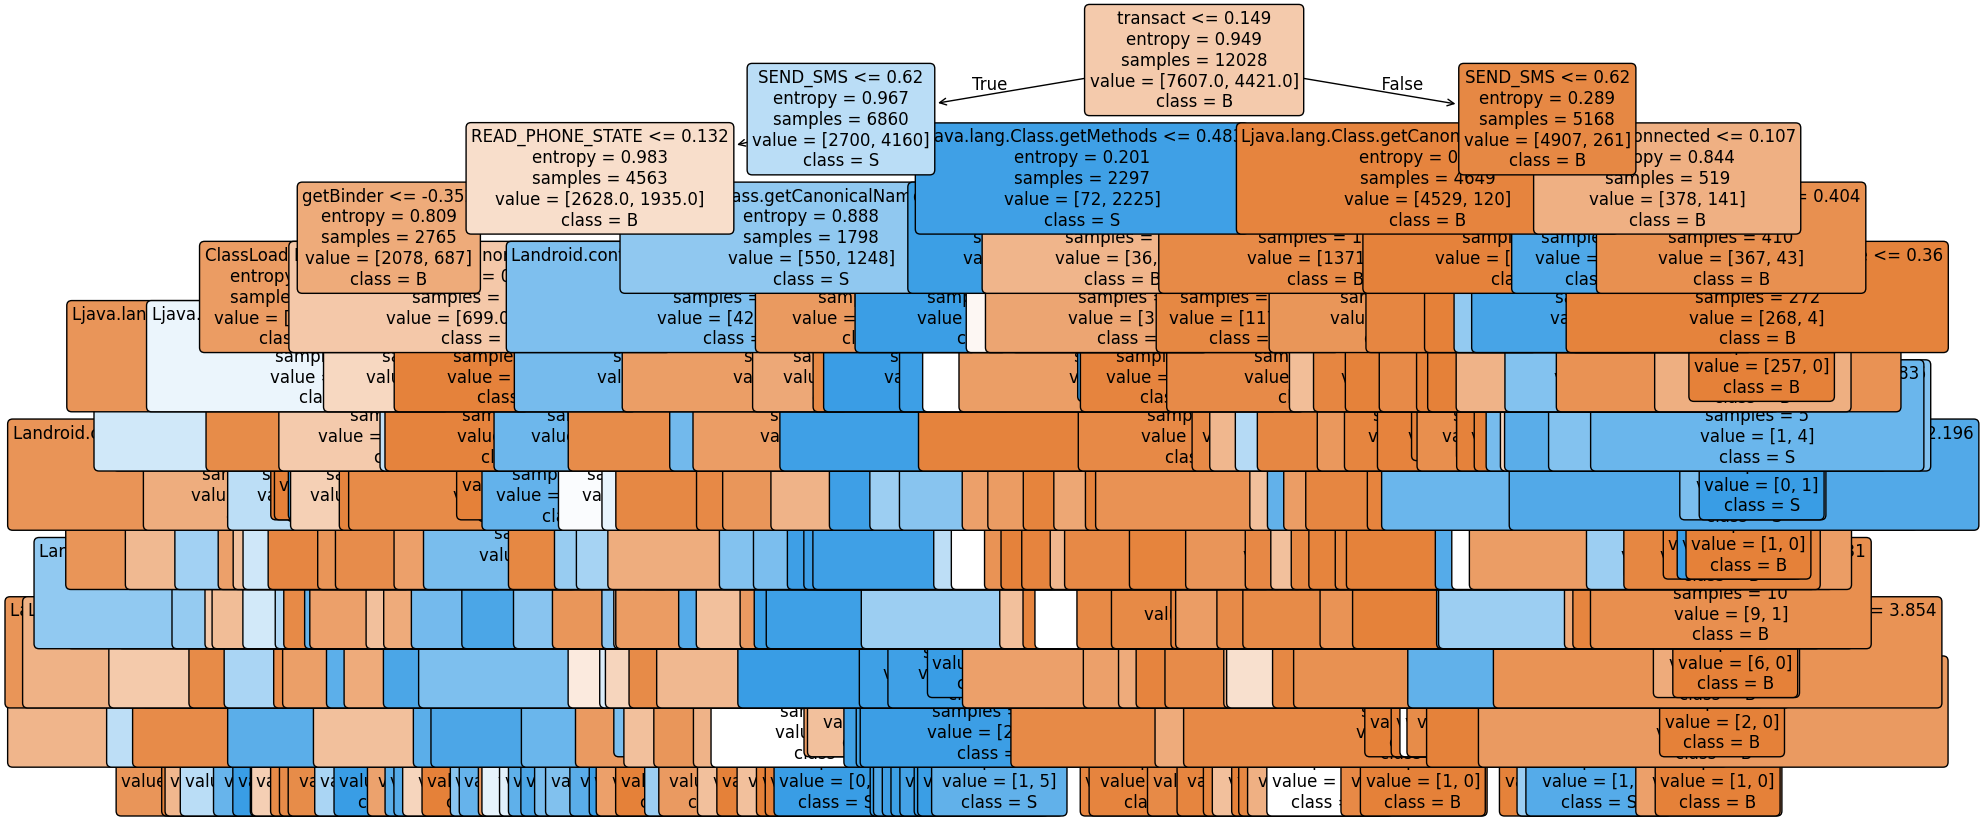

In [107]:
# Set the figure size for clarity
plt.figure(figsize=(20,10))

# Visualise the decision tree
# feature_names shows the actual names and not the numeric values of X
plot_tree(malclass_tree, 
          feature_names=drebin_df.columns[0:19], 
          class_names=['B', 'S'], 
          filled=True, 
          rounded=True, 
          fontsize=12)

plt.show()

Step 10.4 - Visualising the impact of depth on accuracy

In the code below I define a function that checks for the error rate of the model as the max depth increases, random_state seed is set to ensure reproucability and ease of bug fixing. Then I train the model and to find the error rate I subtract the accuracy score (how correct the predictions were on training and test data) from 1 (which represents 100% accuracy as this is another mathematical representation of that where 0.01 represents 1%) to find both the training and test data error rate. After this I return the parameters of the function and display a table showing both the error rates for the current max_depth (md) all the way from 1 to 19.

In [108]:
def max_depth_error(max_depths):
    model = DecisionTreeClassifier(max_depth=max_depths, random_state=42)
    model.fit(X_train, y_train)
    training_error = 1 - model.score(X_train, y_train)
    validation_error = 1 - model.score(X_test, y_test)
    return {"Max Depth": max_depths, "Training error": training_error, "Validation Error": validation_error}


max_depth_Df = pd.DataFrame([max_depth_error(md) for md in range(1, 20)])
max_depth_Df

,Max Depth,Training error,Validation Error
0,1,0.246176,0.249668
1,2,0.188560,0.191157
2,3,0.121550,0.112699
3,4,0.112737,0.109043
4,5,0.106501,0.102061
5,6,0.097855,0.093418
6,7,0.091620,0.086436
7,8,0.083721,0.081117
8,9,0.079814,0.077128
9,10,0.076488,0.073803


Step 10.5 - Plotting Accuracy against Depth

As shown in the visualisation directly above and the plot below the error rate of predictions for both the training and validation/test data stops decreasing by substantial amounts when the depth is around 11/12, meaning the ideal tree depth is 12. I will now change my max_depth to 12 and see if the accuracy score from the built in method increases (EDIT: It went up to 0.926529255319149, 93% when rounded). Since that is my highest accuracy score for decision trees (and all classification models) so far I will not increase tree depth as I do not want to overfit the model. The metric I will use to recommend the best performing model is accuracy, if there was mroe time I would take a more hollistic apoproach accounting for model unique things like log loss while assigning weights to each metric and aprameter to then get a performance comparison that is more all-encompassing, but due to time I will not ruminate on that currently.

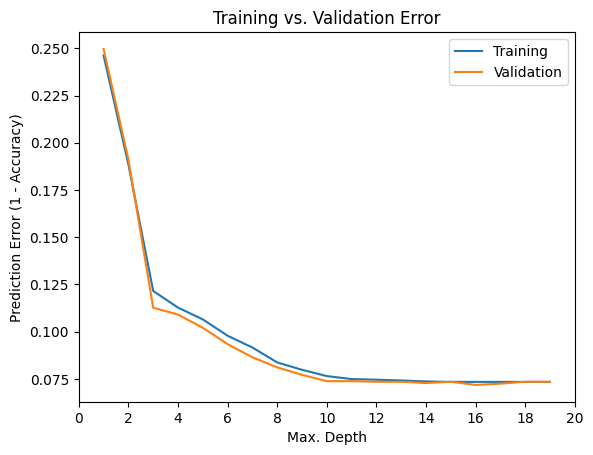

In [109]:
plt.figure()
plt.plot(max_depth_Df['Max Depth'], max_depth_Df['Training error'])
plt.plot(max_depth_Df['Max Depth'], max_depth_Df['Validation Error'])
plt.title('Training vs. Validation Error')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])

Step 11. Strengths and Weaknesses of each approach - Some of the pros and cons of each model have been listed (whilst being tied back to the result/ranking of my chosen classification models), this is by no means all of the pros and cons of any of the models.

Strengths and weaknesses of KNN:
    Advantages:
        ⦁ KNN does not require a training phase as it is a "lazy learner" algorithm and all the computation is done at prediction time, this saves money in events where training time is expensive and immediate predictions are not needed.
        ⦁ KNN can work well with small datasets where the relationships between data poubrs are meaningful and easy to capture using proximity (distance based calculations and closeness to each other).
    Disadvantages:
        ⦁ KNN is sensitive to noise and outliers (RobustScaler would have been used if I had any outlier values) and it also struggles with imbalanced datasets.
        ⦁ KNN like K-Means clustering also suffers from the "curse of dimensionality" where it does not deal with high dimensional data well, as the features increase the distance between points become less meaningful and KNN performance degrades (this is probably why it ranks in 2nd since my data has a lot of features and high dimensionality). The curse of dimensionality involves all data points becoming equally distant from each other in high-dimensional space, thus making it hard for KNN to distinguish relevant neighbours.

Strengths and weaknesses of LR:
    Advantages:
        ⦁ It performs wll with linearly separable datasets.
        ⦁ It is fast at claddifying unknown data.
        ⦁ LR is less inclined to overfitting in high dimensional datasets, regularisation also helps avoid overfitting (my c value for the LR value was as low as it could be. This means that I had high regularisation, as c is an inverse of regularisation, and yet the LR model still performed the worst).
    Disadvantages
        ⦁ It constructs linear boundaries (the dataset is not really linear, as shown with the RBF kernel performing better than the linear kernel for SVM, and models that do not do this/do not involve linearity performing much better than LR. This is probably why LR is 4th).
        ⦁ This ties into the second disadvantage of non-linear problems not being able to be solved with LR due to it having a linear decision surface. Linearly separable data is also rarely found in real-world settings.

Strengths and weaknesses of SVM:
 Advantages:
        ⦁ Performs well in high-dimensional space and has excellent accuracy.
        ⦁ May result in overfitting when the number features are high and the number of samples/rows are low.
    Disadvantages
        ⦁ Does not provide probability estimates like LR.
        ⦁ Computationally expensive for large datasets as it requires a long training period.
        ⦁ Does not perform well with a noisy dataset (such as one with overlapping targets).

Strengths and weaknesses of Decision Trees:
 Advantages:
        ⦁ Decision trees are the most interpretabile model out of my set of classification models used in this Jupyter notebook. They are easy to understand and with lower features, easy to visualise.
        ⦁ It can capture non-linear relationships between features and the target and represent complex decision boundaries, this makes them suitable for datasets with intricate patterns.
        ⦁ They are robust to outliers due to it partitioning the feature space into regions based on the value of features (outliers have little effect on overall model performance). Not really relevant with this dataset though.
        ⦁ It does not need the scaling of features as it is insensitive to that.
    Disadvantages
        ⦁ Difficulty in capturing linear relationships between features and the target variable.
        ⦁ Decision trees are prone to overfitting if the tree is too deep or the dataset is noisy. Pruning is one way to prevent overfitting and involves simplifying the decision tree by removing parts that do not provide a lot of predictive power, thus improving the ability to generalise (draw broad categorical inferences from observations) new data.

Step 12. Conclusion and recommendations



Using the empirical evidence shown through my observations, the accuracy scores, model performance, and my visualisations (of model performance and other data) I have been able to rank the best performing models by the accuracy score of their predictions (using actual y and predicted y values) and the order of highest to lowest also represents my order of recommendation, from most recommended classification model(s) for this use case (prediction class from the drebin dataset features) to least recommended classification model(s):

• 1st. Decision Tree (where max_depth is 12) had the highest accuracy of 0.926529255319149 (93% when rounded to 2dp and multiplied)
• 2nd. KNN (where k=9), with the test set accuracy score of 92.02% (rounded to 2dp then multiplied by 100)
• 3rd. SVM (where RBF is the kernel), with the accuracy score of 91.95% (rounded to 2dp then multiplied by 100)
• 4th. Logistic Regression with the lowest accuracy score of 88%

As seen in the accuracy scores shown earlier, the accuracy scores of KNN and SVM were incredibly close but it does not change the fact that the model I actually recommend is Decision trees, based off of the accuracy score that I observed. 

To conclude, Decision Trees are the best classification model for my given use case and this dataset. Since it was shown that nonlinear classification models performing better than the linear one and RBF doing better than the linear kernel, I have inferred that the data is either nonlinear or at least more nonlinear than it is linear. Experimentation was done, mathematical and data science concepts were discussed and this notebook was faithful to best practice and industry standard processes and procedures.

References:
https://www.ibm.com/think/topics/classification-machine-learning
https://stats.oarc.ucla.edu/other/mult-pkg/whatstat/what-is-the-difference-between-categorical-ordinal-and-interval-variables/
https://stackoverflow.com/questions/155609/whats-the-difference-between-a-method-and-a-function
https://www.geeksforgeeks.org/dsa/introduction-to-algorithms/
https://stackoverflow.com/questions/24251219/pandas-read-csv-low-memory-and-dtype-options
https://www.geeksforgeeks.org/python/pandas-read_csv-low_memory-and-dtype-options/
https://encord.com/blog/classification-metrics-accuracy-precision-recall/
https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall
https://www.nb-data.com/p/is-it-necessary-for-feature-scaling
https://www.digitalocean.com/community/tutorials/python-shape-method
https://www.geeksforgeeks.org/machine-learning/supervised-unsupervised-learning/
https://www.datacamp.com/blog/classification-machine-learning
https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/
https://www.geeksforgeeks.org/machine-learning/what-does-the-fit-method-in-scikit-learn-do/
https://developers.google.com/machine-learning/crash-course/linear-regression/loss
https://www.kaggle.com/discussions/general/220823
https://www.ibm.com/think/topics/loss-function
https://www.ibm.com/think/topics/data-leakage-machine-learning
https://www.iguazio.com/glossary/noise-in-ml/
https://www.geeksforgeeks.org/machine-learning/how-to-handle-noise-in-machine-learning/
https://www.geeksforgeeks.org/machine-learning/an-introduction-to-multilabel-classification/
https://developers.google.com/machine-learning/crash-course/logistic-regression/loss-regularization
https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.jaccard_score.html
https://en.wikipedia.org/wiki/Confusion_matrix
https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/
https://www.geeksforgeeks.org/machine-learning/how-to-normalize-a-confusion-matrix/
https://medium.com/@fzammito/whats-considered-a-good-log-loss-in-machine-learning-a529d400632d
https://www.geeksforgeeks.org/machine-learning/support-vector-machine-algorithm/
https://www.geeksforgeeks.org/machine-learning/how-does-knn-work-for-high-dimensional-data/
https://www.statology.org/high-dimensional-data/
https://deepai.org/machine-learning-glossary-and-terms/high-dimensional-data
https://www.geeksforgeeks.org/machine-learning/managing-high-dimensional-data-in-machine-learning/
https://www.geeksforgeeks.org/machine-learning/feature-selection-for-high-dimensional-data/
https://datascience.stackexchange.com/questions/56263/what-is-sample-and-feature
https://medium.com/@frankcool/data-samples-vs-features-in-machine-learning-b9d4b50c8fce
https://www.geeksforgeeks.org/data-science/what-is-gradient-descent/
https://www.geeksforgeeks.org/machine-learning/f1-score-in-machine-learning/
https://www.statology.org/what-is-a-good-f1-score/
https://en.wikipedia.org/wiki/Logistic_regression
https://cocalc.com/github/danielbarnes18/ibm-data-science-professional-certificate/blob/main/09.%20Machine%20Learning%20with%20Python/03.%20Classification/02.%20Decision%20Trees.ipynb
https://www.kaggle.com/code/darrylljk/decision-trees
https://www.geeksforgeeks.org/machine-learning/decision-tree/
https://koshurai.medium.com/understanding-log-loss-the-math-behind-it-and-why-it-matters-for-machine-learning-success-22c10276560a
https://www.geeksforgeeks.org/machine-learning/how-decision-tree-depth-impact-on-the-accuracy/
https://medium.com/@jing.wang.ds/what-are-knns-advantages-and-disadvantages-compared-to-the-other-popular-machine-learning-models-b171c48dd817
https://www.geeksforgeeks.org/data-science/advantages-and-disadvantages-of-logistic-regression/
https://stats.stackexchange.com/questions/178522/why-knn-is-a-non-linear-classifier
https://roboticsbiz.com/pros-and-cons-of-support-vector-machine-svm/
https://www.geeksforgeeks.org/machine-learning/pros-and-cons-of-decision-tree-regression-in-machine-learning/
https://www.geeksforgeeks.org/machine-learning/pruning-decision-trees/
https://www.immuta.com/blog/what-is-data-generalization/
https://pubmed.ncbi.nlm.nih.gov/20598692/
https://www.geeksforgeeks.org/data-science/basic-approaches-for-data-generalization-dwdm/
https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/

Y4 ML4DA module materials were also consulted, as is customary to my notebooks this year.